ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [64]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

_Write your calculations and explanation here. You may use Python below if you want, but final reasoning must be readable._

Dataset: [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

Step 1: I sorted the data in ascending order

[30, 31, 32, 32, 33, 33, 34, 34 35, 500]

Step 2: Median of the data
  
There are 10(even) values, so median = average of the 5th and 6th values
  
5th value = 33
  
6th value = 33

Medain = 33+33/2 = 33

Step 3: IQR of data

Lower half(first 5 values): 30, 31, 32, 32, 33
  
Median of Lower half, Q1 = middle value = 32
  
Upper half(last 5 values): 33, 34, 34 35, 500
  
Median of Upper half, Q3 = middle value = 34

IQR = Q3 - Q1 = 34 - 32 = 2

Step 4: Outlier check using IQR

Lower Fence, LF = Q1 - 1.5 * IQR = 32 - 1.5 * 2 = 29

Upper Fence, UF = Q1 + 1.5 * IQR = 32 + 1.5 * 2 = 37

Outlier = Any value < LF or Any value > UF

Since 500 > 37, 500 is an outlier

Explanation:
Median and IQR are better for this dataset because Median and IQR don't get affected by extreme values like 500. Mean and Standard Deviation would be pulled a lot by this large number, so they wouldn't show the real pattern. Median and IQR ignore the effect of extreme values, so they describe the customer spending more accurately.

In [103]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

# Sort the data
dt_sort = sorted(data_q1)
print('Sorted Data:', dt_sort)

# Compute Median
med = np.median(dt_sort)
print("Median (Q2):", med)

# Compute Q1 and Q2
q1 = np.percentile(dt_sort, 25)
q3 = np.percentile(dt_sort, 75)

# Compute IQR
iqr = q3 - q1
print("IQR:", iqr)

# Compute fences
lf = q1 - 1.5 * iqr
uf = q3 + 1.5 * iqr
print("Lower Fence (LF):", lf)
print("Upper Fence (UF):", uf)

outlier = [x for x in dt_sort if x < lf or x > uf]
print("Outlier:", outlier)

Sorted Data: [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]
Median (Q2): 33.0
IQR: 2.0
Lower Fence (LF): 29.0
Upper Fence (UF): 37.0
Outlier: [500]


### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

_Write your step by step Bayes calculation and explanation here._

1.Bayes Theorem Formula:

P(A|B) = (P(B|A) * P(A)) / P(B)

Here, let:

*   A = Disease
*   B = Test+(Test Positive)

     PPV = P(Disease|Test+) = P(Test+ | Disease) * P(Disease) / P(Test+)

Given:
  *   Prevalence P(Disease) = 1% = 0.01
  *   Sensitivity P(Test+ | Disease) = 90% = 0.90
  *   Specificity P(Test- | NoDisease) = 92% = 0.92

Step 1:

True Positive(TP):

TP = Sensitivity * Prevalence = 0.09 * 0.01 = 0.009

False Positive(FP):

FP = (1 - Specificity) * (1 - Prevalence) = (1 - 0.92) * (1 - 0.01) = 0.08 * 0.99 = 0.0792

Step 2: Positive Predictive Value

PPV = TP / (TP + FP) = 0.009 / (0.009 + 0.0792) = 0.009 / 0.0882 ≈ 0.102

PPV ≈ 10.2%

2.If prevalence rises to 20%, the numerator (TP fraction) increases more than the FP fraction. Therefore, a positive test result is more likely to be a true positive. PPV increases as prevalence increases. Bayes theorem shows that PPV depends directly on prevalence, sensitivity and specificity.

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_Write your task type, preprocessing list, and pipeline paragraph here._

1.This is a binary classification task because the target premium_user has two classes (0 or 1).

2.Four reasonable preprocessing steps:

*   Handle missing value in numeric and categorical columns
*   Encode the categorical column region using one-hot encoding or similar methods
*   Scale numeric features (age, daily_clicks) using standardization or normalization
*   Split the dataset into training and testing sets to evaluate the model fairly

3.End-to-end ML pipeline:
First, I would inspect the raw data and fix any missing or inconsistent values. Then, I would convert the region column into numeric form using one-hot encoding and scale the numeric columns like age and daily_clicks so the model can learn better. Next, I would split the dataset into training and testing sets, usually 80% for training and 20% for testing. After that, I would choose a binary classification model such as logistic regression, decision tree and train it on the prepared data. I would also tune the model's hyperparameters using cross-validation to get better performance. Finally, I would evaluate the model on the test set using metrics like accuracy, precision, recall and F1-score. This process helps ensure the data is clean, the model learns well and the results are reliable.

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [54]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

1.**Compact EDA**

In [55]:
# Missing value summary
miss_summary = df.isnull().sum()

miss_summary

,0
age,2
region,0
purchases,1
premium_user,0


In [56]:
# Unique values per column
unique = df.nunique()

unique

,0
age,5
region,4
purchases,6
premium_user,2


In [57]:
# Correlation among numeric columns

correlation = df.corr(numeric_only=True)

correlation

,age,purchases,premium_user
age,1.000000,0.923677,0.789534
purchases,0.923677,1.000000,0.825860
premium_user,0.789534,0.825860,1.000000


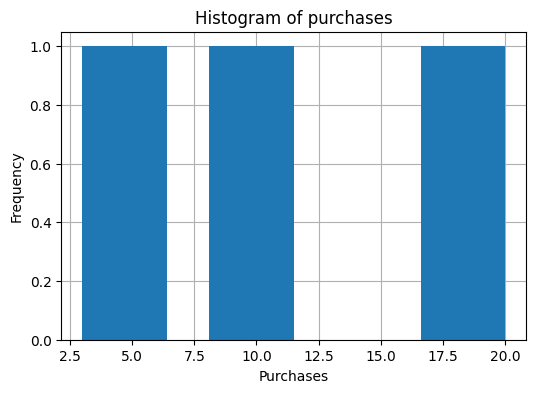

In [58]:
# Histogram of purchases

plt.figure()
plt.hist(df['purchases'], zorder=2)
plt.title("Histogram of purchases")
plt.xlabel('Purchases')
plt.ylabel('Frequency')
plt.show()

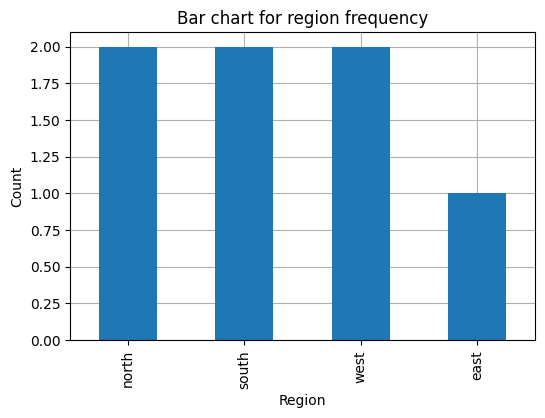

In [59]:
# Bar chart for region frequency

plt.figure()
df['region'].value_counts().plot(kind="bar", zorder=2)
plt.title("Bar chart for region frequency")
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

2.**Preprocessing**

In [60]:
df_processed = df.copy()

df_processed

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


In [61]:
# Impute age with median

df_processed['age'] = df_processed['age'].fillna(df_processed['age'].median())

df_processed

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,30.0,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,30.0,south,9.0,0


In [62]:
# Impute purchases with mean

df_processed['purchases'] = df_processed['purchases'].fillna(df_processed['purchases'].mean())

df_processed

,age,region,purchases,premium_user
0,25.0,north,3.000000,0
1,30.0,south,10.000000,1
2,30.0,north,5.000000,0
3,22.0,east,10.833333,0
4,45.0,west,20.000000,1
5,52.0,west,18.000000,1
6,30.0,south,9.000000,0


In [63]:
# One-hot encode region

ohe_region = pd.get_dummies(df_processed['region'], prefix="Region", dtype=int)

df_processed = pd.concat([df_processed, ohe_region], axis=1)

df_processed = df_processed.drop(columns=['region'])

df_processed

,age,purchases,premium_user,Region_east,Region_north,Region_south,Region_west
0,25.0,3.000000,0,0,1,0,0
1,30.0,10.000000,1,0,0,1,0
2,30.0,5.000000,0,0,1,0,0
3,22.0,10.833333,0,1,0,0,0
4,45.0,20.000000,1,0,0,0,1
5,52.0,18.000000,1,0,0,0,1
6,30.0,9.000000,0,0,0,1,0


In [65]:
# Scale all numeric columns using RobustScaler

scaler = RobustScaler()
num_cols = ['age', 'purchases']
df_processed[num_cols] = scaler.fit_transform(df_processed[num_cols])

df_processed

,age,purchases,premium_user,Region_east,Region_north,Region_south,Region_west
0,-0.5,-0.943820,0,0,1,0,0
1,0.0,0.000000,1,0,0,1,0
2,0.0,-0.674157,0,0,1,0,0
3,-0.8,0.112360,0,1,0,0,0
4,1.5,1.348315,1,0,0,0,1
5,2.2,1.078652,1,0,0,0,1
6,0.0,-0.134831,0,0,0,1,0


**3.Domain Driven Feature**

In [67]:
# High spender based on purchases

df_processed['high_spender'] = (df['purchases'].fillna(df['purchases'].mean()) > df['purchases'].median()).astype(int)

# Final transformed dataframe
df_processed

,age,purchases,premium_user,Region_east,Region_north,Region_south,Region_west,high_spender
0,-0.5,-0.943820,0,0,1,0,0,0
1,0.0,0.000000,1,0,0,1,0,1
2,0.0,-0.674157,0,0,1,0,0,0
3,-0.8,0.112360,0,1,0,0,0,1
4,1.5,1.348315,1,0,0,0,1,1
5,2.2,1.078652,1,0,0,0,1,1
6,0.0,-0.134831,0,0,0,1,0,0


---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [68]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

Step 2: Split the data
- I split the data into 80% train and 20% test

In [70]:
X = df2[['area_sqft', 'bedrooms']]
y = df2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 3: Fit Linear Regression Model
- I used LinearRegression to predict price from area_sqft and bedrooms

In [71]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 4: Print model intercept, coefficients and predictions

In [79]:
print("Intercept:", model.intercept_)
print("Coefficients:", list(zip(X.columns, model.coef_)))
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Intercept: -33.84615384615387
Coefficients: [('area_sqft', np.float64(0.15384615384615388)), ('bedrooms', np.float64(5.384615384615377))]
Predictions: [100.         130.76923077]


Step 5: Compute metrics on test set
- I calculated MAE, RMSE and R² for model performance

In [80]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 19.615384615384613
Root Mean Squared Error (RMSE): 19.61915499208746
R-squared (R²): -0.7107166337935567


Step 6: Residual plot
- I plotted residuals (y_true - y_pred) to check for patterns

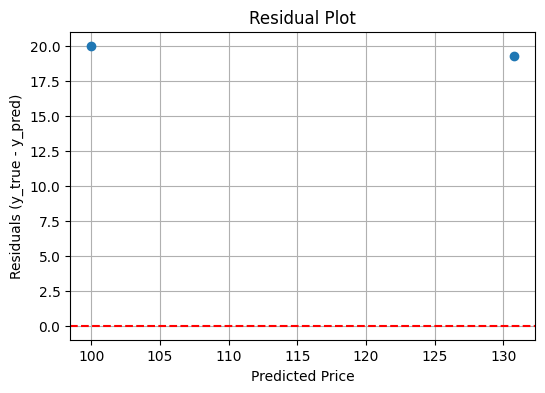

In [84]:
from matplotlib import lines
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, zorder=2)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (y_true - y_pred)")
plt.show()

Observation:
All residuals are above zero, which means the model under-predicted the actual prices for these points. Ideally, residuals should be scattered around zero, but here the predictions are slightly lower than the actual values.

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [91]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below
threshold_1 = 0.5
y_pred_0_5 = (y_prob >= threshold_1).astype(int)

cm_0_5 = confusion_matrix(y_true, y_pred_0_5)
pcsn_0_5 = precision_score(y_true, y_pred_0_5)
rcl_0_5 = recall_score(y_true, y_pred_0_5)
f1_0_5 = f1_score(y_true, y_pred_0_5)

print("Threshold 0.5:")
print("Confusion Matrix:\n", cm_0_5)
print("Precision:", pcsn_0_5)
print("Recall:", rcl_0_5)
print("F1 Score:", f1_0_5)

threshold_2 = 0.3
y_pred_0_3 = (y_prob >= threshold_2).astype(int)

cm_0_3 = confusion_matrix(y_true, y_pred_0_3)
pcsn_0_3 = precision_score(y_true, y_pred_0_3)
rcl_0_3 = recall_score(y_true, y_pred_0_3)
f1_0_3 = f1_score(y_true, y_pred_0_3)

print("Threshold 0.3:")
print("Confusion Matrix:\n", cm_0_3)
print("Precision:", pcsn_0_3)
print("Recall:", rcl_0_3)
print("F1 Score:", f1_0_3)


Threshold 0.5:
Confusion Matrix:
 [[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Threshold 0.3:
Confusion Matrix:
 [[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall: 1.0
F1 Score: 0.8333333333333334


Explanation:

When we lower the threshold from 0.5 to 0.3, the model starts calling more samples "positive". This helps the model catch all the actual positive cases, so recall stays high at 1.0. But because it also turns some negative samples into positive by mistake, the precision goes down. In simple words, lowering the threshold makes the model less strict - it finds more positves, but also makes more errors.

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._

Part 2: ROC and AUC

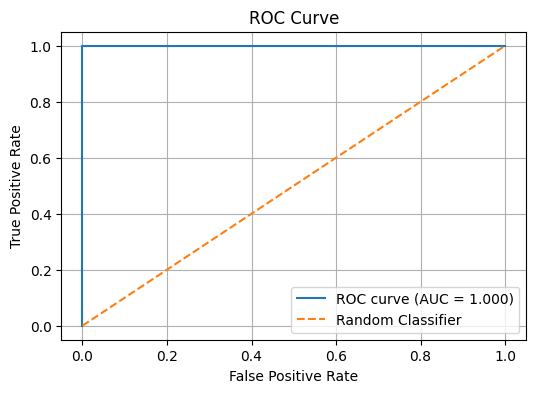


AUC: 1.000


In [93]:
# ROC values
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# compute AUC
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# print AUC
print(f"\nAUC: {roc_auc:.3f}")

Explanation: A high AUC means the model can clearly separate positive and negative classes, making very accurate predictions. A low AUC means the model cannot distinguish between the classes well.

Part 3: Decision Tree

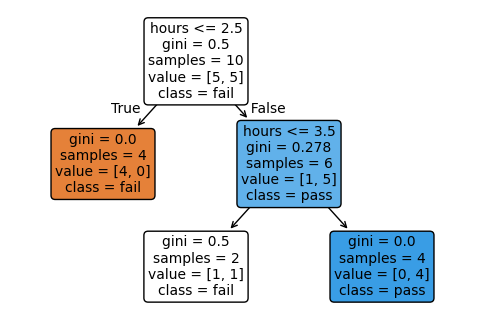

In [99]:
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

X = df3[['hours']]
y = df3['passed']

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)

# Plot for tree
plot_tree(
    model,
    feature_names=['hours'],
    class_names=['fail', 'pass'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Explanation: The decision tree has a small depth(max_depth=2), it can't grow too complex, so it is less likely to overfit. The dataset is also very small and has only one feature, so the model should generalize reasonably well. If the tree were deeper, it might start memorizing the data, but at this depth it stays simple and reasonable.